# Gender Bias Exploration — Logistic Regression

**Model rationale for ADNI data:**  
Logistic Regression with L2 regularization is the most interpretable classifier. In clinical settings, LR coefficients directly map to log-odds ratios for each biomarker, making it preferable when model transparency is required. It handles the 129-feature space well with L2 regularization.

Hyperparameters: C=1.0, penalty='l2', max_iter=1000.

**6 debiasing methods × 2 imbalance modes = 12 configurations.**

In [1]:
%matplotlib inline
from exploration_utils import *
from IPython.display import display, Markdown

I0000 00:00:1781881483.641132   44969 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781881483.641549   44969 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781881483.673858   44969 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781881484.385895   44969 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
df = load_adni_data()
print('Original shape:', df.shape)
df = drop_metadata(df)
print('After dropping metadata:', df.shape)
display(df.head(2))

Original shape: (757, 147)
After dropping metadata: (757, 129)


,DIAGNOSIS,Sex,age,DXNODEP,DXPARK,DXPDES,DXPCOG,DXPATYP,DXDEP,DXOTHDEM,...,RIGHT_BA36_VOL,RIGHT_BA36_NS,RIGHT_PHC_VOL,RIGHT_PHC_NS,RIGHT_SULCUS_VOL,RIGHT_SULCUS_NS,RIGHT_CA_VOL,RIGHT_CA_NS,RIGHT_HIPP_VOL,RIGHT_HIPP_NS
0,0,0,57.9,0,0,0,0,0,0,0,...,0.099781,12.0,0.040663,7.0,0.017779,18.0,0.094855,20.0,0.153476,20.0
1,0,0,66.4,0,0,0,0,0,0,0,...,0.122244,14.0,0.043713,8.0,0.015407,20.0,0.087257,21.0,0.132635,21.0


In [3]:
dataset = make_bld(df)
dataset_train, dataset_val = split_dataset(dataset)
print(f'Train: {dataset_train.features.shape}, Val: {dataset_val.features.shape}')

m_train = BinaryLabelDatasetMetric(dataset_train,
    unprivileged_groups=UNPRIVILEGED_GROUPS, privileged_groups=PRIVILEGED_GROUPS)
m_val = BinaryLabelDatasetMetric(dataset_val,
    unprivileged_groups=UNPRIVILEGED_GROUPS, privileged_groups=PRIVILEGED_GROUPS)
print(f'Training disparate impact = {m_train.disparate_impact():.4f}')
print(f'Validation disparate impact = {m_val.disparate_impact():.4f}')

Train: (499, 128), Val: (258, 128)
Training disparate impact = 0.8232
Validation disparate impact = 1.1675


---
## Baseline (no debiasing)

**Rationale:** Baseline LR — most interpretable model; establishes how much bias a simple linear decision boundary exhibits.

In [4]:
res_lr_base_smote = run_comparison(
    'lr', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='None')


  LR | None | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.0100
  Metrics:
  Balanced accuracy = 0.8516
  Average odds difference = -0.0413
  Disparate impact = 0.9487
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0171
  Theil index = 0.0708

  Cases improved by debiasing: 0


  0%|          | 0/13 [00:00<?, ?it/s]


  --- T-tests (baseline) ---

  Significant (males, baseline):
    DXPARK <= -0.12: T=24.880, p=0.000000
    CDCARE <= -0.43: T=22.330, p=0.000000
    GENOTYPE_2/3 <= -0.25: T=-9.046, p=0.000041

  Significant (females, baseline):
    DXPARK <= -0.12: T=20.273, p=0.000035
    PTMARRY <= -0.43: T=18.184, p=0.000054
    WORD2DL_x <= -0.86: T=24.567, p=0.000016
    GENOTYPE_4/4 <= -0.46: T=-15.478, p=0.000102

  --- T-tests (debiased) ---

  Significant (males, debiased):
    DXPARK <= -0.12: T=24.880, p=0.000000
    CDCARE <= -0.43: T=22.330, p=0.000000
    GENOTYPE_2/3 <= -0.25: T=-9.046, p=0.000041

  Significant (females, debiased):
    DXPARK <= -0.12: T=20.273, p=0.000035
    PTMARRY <= -0.43: T=18.184, p=0.000054
    WORD2DL_x <= -0.86: T=24.567, p=0.000016
    GENOTYPE_4/4 <= -0.46: T=-15.478, p=0.000102


In [5]:
res_lr_base_cw = run_comparison(
    'lr', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='None')


  LR | None | class_weight

  --- Baseline model ---
  Threshold: 0.0199
  Metrics:
  Balanced accuracy = 0.8491
  Average odds difference = -0.0459
  Disparate impact = 0.9290
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0242
  Theil index = 0.0717

  Cases improved by debiasing: 0


  0%|          | 0/13 [00:00<?, ?it/s]


  --- T-tests (baseline) ---

  Significant (males, baseline):
    PTETHCAT <= 0.23: T=-9.667, p=0.000027
    DXPARK <= -0.11: T=43.460, p=0.000000
    GENOTYPE_2/4 <= -0.17: T=-8.620, p=0.000056
    CDCARE <= -0.29: T=29.095, p=0.000000
    FAQFORM > 0.89: T=15.284, p=0.000001
    FAQSHOP > 0.07: T=19.401, p=0.000000
    GENOTYPE_2/3 <= -0.26: T=-16.382, p=0.000001
    FAQREM > 0.67: T=11.507, p=0.000008
    FAQMEAL > 0.11: T=8.448, p=0.000064

  Significant (females, baseline):
    DXPARK <= -0.11: T=58.434, p=0.000001
    FAQSHOP > 0.07: T=45.411, p=0.000001
    FAQBEVG <= -0.35: T=17.499, p=0.000063

  --- T-tests (debiased) ---

  Significant (males, debiased):
    PTETHCAT <= 0.23: T=-9.667, p=0.000027
    DXPARK <= -0.11: T=43.460, p=0.000000
    GENOTYPE_2/4 <= -0.17: T=-8.620, p=0.000056
    CDCARE <= -0.29: T=29.095, p=0.000000
    FAQFORM > 0.89: T=15.284, p=0.000001
    FAQSHOP > 0.07: T=19.401, p=0.000000
    GENOTYPE_2/3 <= -0.26: T=-16.382, p=0.000001
    FAQREM > 0.67:

---
## DisparateImpactRemover (DIR)

**Rationale:** DIR's percentile-based feature repair is well-suited to linear models — it removes rank correlation without altering the linear structure of the decision boundary.

In [6]:
res_lr_dir_smote = run_comparison(
    'lr', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='DIR')


  LR | DIR | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.0100
  Metrics:
  Balanced accuracy = 0.8516
  Average odds difference = -0.0413
  Disparate impact = 0.9487
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0171
  Theil index = 0.0708
  --- Debiased model (DIR) ---
  Threshold: 0.0199
  Metrics:
  Balanced accuracy = 0.8808
  Average odds difference = -0.0241
  Disparate impact = 1.0294
  Equal opportunity difference = -0.0343
  Statistical parity difference = 0.0100
  Theil index = 0.0553

  Cases improved by debiasing: 8
     y_true  pred_orig  pred_deb     Sex
3       0.0        1.0       0.0    Male
29      0.0        1.0       0.0    Male
39      1.0        0.0       1.0  Female
52      0.0        1.0       0.0    Male
64      0.0        1.0       0.0  Female
153     1.0        0.0       1.0    Male
187     1.0        0.0       1.0    Male
244     1.0        0.0       1.0  Female


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]


  --- T-tests (baseline) ---

  Significant (males, baseline):
    DXPARK <= -0.12: T=29.449, p=0.000000
    PTETHCAT <= 0.20: T=-8.100, p=0.000084
    CDCARE <= -0.43: T=34.011, p=0.000000
    FAQGAME > 0.98: T=-15.347, p=0.000001

  Significant (females, baseline):
    DXPARK <= -0.12: T=52.497, p=0.000001
    GENOTYPE_4/4 <= -0.46: T=-17.898, p=0.000057

  --- T-tests (debiased) ---

  Significant (males, debiased):
    DXPARK <= -0.13: T=24.669, p=0.000000
    CDCARE <= -0.40: T=17.934, p=0.000000
    GENOTYPE_2/3 <= -0.24: T=-21.714, p=0.000000
    Sex <= -0.92: T=-10.947, p=0.000012

  Significant (females, debiased):
    0.45 < PTETHCAT <= 0.93: T=26.693, p=0.000012
    PTORIENT <= -0.51: T=-17.411, p=0.000064
    WORD2DL_x <= -0.87: T=15.858, p=0.000092


In [7]:
res_lr_dir_cw = run_comparison(
    'lr', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='DIR')


  LR | DIR | class_weight

  --- Baseline model ---


  Threshold: 0.0199
  Metrics:
  Balanced accuracy = 0.8491
  Average odds difference = -0.0459
  Disparate impact = 0.9290
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0242
  Theil index = 0.0717
  --- Debiased model (DIR) ---
  Threshold: 0.0298
  Metrics:
  Balanced accuracy = 0.8680
  Average odds difference = -0.0471
  Disparate impact = 0.9323
  Equal opportunity difference = -0.0343
  Statistical parity difference = -0.0255
  Theil index = 0.0592

  Cases improved by debiasing: 7
     y_true  pred_orig  pred_deb     Sex
3       0.0        1.0       0.0    Male
29      0.0        1.0       0.0    Male
39      1.0        0.0       1.0  Female
64      0.0        1.0       0.0  Female
70      1.0        0.0       1.0    Male
153     1.0        0.0       1.0    Male
244     1.0        0.0       1.0  Female


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]


  --- T-tests (baseline) ---

  Significant (males, baseline):
    PTETHCAT <= 0.23: T=-10.422, p=0.000016
    DXPARK <= -0.11: T=21.745, p=0.000000
    GENOTYPE_2/4 <= -0.17: T=-11.084, p=0.000011
    CDCARE <= -0.29: T=15.373, p=0.000001
    GENOTYPE_2/3 <= -0.26: T=-9.502, p=0.000030
    FAQSHOP > 0.07: T=18.344, p=0.000000
    FAQFORM > 0.89: T=15.229, p=0.000001
    FAQREM > 0.67: T=11.108, p=0.000011
    FAQGAME > 0.74: T=-9.190, p=0.000037

  Significant (females, baseline):
    FAQBEVG <= -0.35: T=15.826, p=0.000093

  --- T-tests (debiased) ---

  Significant (males, debiased):
    DXPARK <= -0.11: T=28.658, p=0.000000
    CDCARE <= -0.26: T=26.913, p=0.000000
    GENOTYPE_2/3 <= -0.26: T=-11.456, p=0.000009
    FAQSHOP > 0.07: T=19.284, p=0.000000
    FAQFORM > 0.89: T=16.257, p=0.000001
    FAQMEAL > 0.11: T=9.630, p=0.000027

  Significant (females, debiased):
    DXPARK <= -0.11: T=15.196, p=0.000109
    -0.90 < PTETHCAT <= 0.89: T=43.597, p=0.000002
    PTORIENT <= -0.53

---
## Reweighing

**Rationale:** LR's convex loss function responds predictably to sample weights — Reweighing adjusts the loss contribution per sample to achieve demographic parity.

In [8]:
res_lr_rw_smote = run_comparison(
    'lr', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='Reweighing')


  LR | Reweighing | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.0100
  Metrics:
  Balanced accuracy = 0.8516
  Average odds difference = -0.0413
  Disparate impact = 0.9487
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0171
  Theil index = 0.0708
  --- Debiased model (Reweighing) ---
  Threshold: 0.0100
  Metrics:
  Balanced accuracy = 0.8596
  Average odds difference = -0.0252
  Disparate impact = 0.9744
  Equal opportunity difference = -0.0040
  Statistical parity difference = -0.0085
  Theil index = 0.0667

  Cases improved by debiasing: 1
     y_true  pred_orig  pred_deb     Sex
244     1.0        0.0       1.0  Female


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]


  --- T-tests (baseline) ---

  Significant (males, baseline):
    DXPARK <= -0.12: T=24.792, p=0.000000
    PTETHCAT <= 0.20: T=-9.106, p=0.000040
    CDCARE <= -0.43: T=39.900, p=0.000000
    FAQGAME > 0.98: T=-8.615, p=0.000057

  No significant features (females, baseline)

  --- T-tests (debiased) ---

  Significant (males, debiased):
    DXPARK <= -0.12: T=27.130, p=0.000000
    CDCARE <= -0.43: T=31.243, p=0.000000
    GENOTYPE_2/3 <= -0.25: T=-19.201, p=0.000000
    FAQGAME > 0.98: T=-9.076, p=0.000040
    GENOTYPE_2/4 <= -0.21: T=-8.528, p=0.000060

  Significant (females, debiased):
    DXPARK <= -0.12: T=15.746, p=0.000095
    WORD2DL_x <= -0.86: T=16.028, p=0.000089


In [9]:
res_lr_rw_cw = run_comparison(
    'lr', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='Reweighing')


  LR | Reweighing | class_weight

  --- Baseline model ---
  Threshold: 0.0199
  Metrics:
  Balanced accuracy = 0.8491
  Average odds difference = -0.0459
  Disparate impact = 0.9290
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0242
  Theil index = 0.0717
  --- Debiased model (Reweighing) ---
  Threshold: 0.0199
  Metrics:
  Balanced accuracy = 0.8491
  Average odds difference = -0.0459
  Disparate impact = 0.9290
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0242
  Theil index = 0.0717

  Cases improved by debiasing: 0


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]


  --- T-tests (baseline) ---

  Significant (males, baseline):
    DXPARK <= -0.11: T=29.586, p=0.000000
    GENOTYPE_2/3 <= -0.26: T=-12.227, p=0.000006
    CDCARE <= -0.29: T=19.663, p=0.000000
    FAQSHOP > 0.07: T=14.542, p=0.000002
    FAQFORM > 0.89: T=24.170, p=0.000000
    GENOTYPE_3/3 <= -0.92: T=12.556, p=0.000005

  Significant (females, baseline):
    DXPARK <= -0.11: T=23.750, p=0.000019
    PTORIENT <= -0.53: T=-20.476, p=0.000034

  --- T-tests (debiased) ---

  Significant (males, debiased):
    DXPARK <= -0.11: T=33.444, p=0.000000
    CDCARE <= -0.29: T=33.642, p=0.000000
    GENOTYPE_2/4 <= -0.17: T=-9.071, p=0.000041
    FAQFORM > 0.89: T=26.761, p=0.000000
    PTNOTRT <= 0.39: T=-10.595, p=0.000015
    GENOTYPE_2/3 <= -0.26: T=-10.716, p=0.000014
    FAQSHOP > 0.07: T=15.636, p=0.000001

  Significant (females, debiased):
    DXPARK <= -0.11: T=15.746, p=0.000095


---
## AdversarialDebiasing

**Rationale:** AdversarialDebiasing transforms features to be sex-agnostic. For a linear model, this tests whether removing gender-correlated linear components from features reduces bias.

In [10]:
res_lr_ad_smote = run_comparison(
    'lr', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='AdversarialDebiasing')


  LR | AdversarialDebiasing | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.0100
  Metrics:
  Balanced accuracy = 0.8516
  Average odds difference = -0.0413
  Disparate impact = 0.9487
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0171
  Theil index = 0.0708
Instructions for updating:
non-resource variables are not supported in the long term


Instructions for updating:
non-resource variables are not supported in the long term
E0000 00:00:1781881545.299062   44969 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1781881545.600246   44969 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


epoch 0; iter: 0; batch classifier loss: 3.582836; batch adversarial loss: 0.821206
epoch 1; iter: 0; batch classifier loss: 1.813476; batch adversarial loss: 0.754385
epoch 2; iter: 0; batch classifier loss: 1.541845; batch adversarial loss: 0.676768
epoch 3; iter: 0; batch classifier loss: 1.115070; batch adversarial loss: 0.693075
epoch 4; iter: 0; batch classifier loss: 0.997277; batch adversarial loss: 0.702654
epoch 5; iter: 0; batch classifier loss: 0.669484; batch adversarial loss: 0.727180
epoch 6; iter: 0; batch classifier loss: 1.057410; batch adversarial loss: 0.767312
epoch 7; iter: 0; batch classifier loss: 1.071814; batch adversarial loss: 0.718729
epoch 8; iter: 0; batch classifier loss: 0.752458; batch adversarial loss: 0.715241
epoch 9; iter: 0; batch classifier loss: 0.478501; batch adversarial loss: 0.710721
epoch 10; iter: 0; batch classifier loss: 0.650951; batch adversarial loss: 0.698744
epoch 11; iter: 0; batch classifier loss: 0.906446; batch adversarial loss:

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]


  --- T-tests (baseline) ---

  Significant (males, baseline):
    PTETHCAT <= 0.20: T=-10.835, p=0.000013
    DXPARK <= -0.12: T=26.523, p=0.000000
    CDCARE <= -0.43: T=31.971, p=0.000000
    FAQGAME > 0.98: T=-10.081, p=0.000020

  Significant (females, baseline):
    WORD2DL_x <= -0.86: T=24.027, p=0.000018
    PTORIENT <= -0.51: T=-21.358, p=0.000028

  --- T-tests (debiased) ---

  Significant (males, debiased):
    DXPARK <= -0.12: T=43.481, p=0.000000
    CDCARE <= -0.43: T=27.249, p=0.000000
    FAQGAME > 0.98: T=-29.971, p=0.000000
    GENOTYPE_2/3 <= -0.25: T=-9.111, p=0.000039

  Significant (females, debiased):
    DXPARK <= -0.12: T=18.053, p=0.000055
    WORD2DL_x <= -0.86: T=73.524, p=0.000000


In [11]:
res_lr_ad_cw = run_comparison(
    'lr', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='AdversarialDebiasing')


  LR | AdversarialDebiasing | class_weight

  --- Baseline model ---
  Threshold: 0.0199
  Metrics:
  Balanced accuracy = 0.8491
  Average odds difference = -0.0459
  Disparate impact = 0.9290
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0242
  Theil index = 0.0717
epoch 0; iter: 0; batch classifier loss: 3.413826; batch adversarial loss: 0.938712
epoch 1; iter: 0; batch classifier loss: 1.259236; batch adversarial loss: 0.742084
epoch 2; iter: 0; batch classifier loss: 0.984820; batch adversarial loss: 0.739368
epoch 3; iter: 0; batch classifier loss: 1.278161; batch adversarial loss: 0.737848
epoch 4; iter: 0; batch classifier loss: 1.060413; batch adversarial loss: 0.719971
epoch 5; iter: 0; batch classifier loss: 0.658150; batch adversarial loss: 0.726243
epoch 6; iter: 0; batch classifier loss: 0.775529; batch adversarial loss: 0.747437
epoch 7; iter: 0; batch classifier loss: 0.689514; batch adversarial loss: 0.727803
epoch 8; iter: 0; batch clas

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]


  --- T-tests (baseline) ---

  Significant (males, baseline):
    DXPARK <= -0.11: T=15.052, p=0.000001
    CDCARE <= -0.29: T=35.084, p=0.000000
    GENOTYPE_2/4 <= -0.17: T=-8.198, p=0.000078
    FAQSHOP > 0.07: T=15.609, p=0.000001
    FAQFORM > 0.89: T=14.180, p=0.000002
    GENOTYPE_2/3 <= -0.26: T=-11.364, p=0.000009
    FAQREM > 0.67: T=21.637, p=0.000000

  Significant (females, baseline):
    FAQSHOP > 0.07: T=17.923, p=0.000057
    WORD2DL_x <= -1.21: T=18.094, p=0.000055

  --- T-tests (debiased) ---

  Significant (males, debiased):
    PTETHCAT <= 0.23: T=-9.242, p=0.000036
    DXPARK <= -0.11: T=30.911, p=0.000000
    GENOTYPE_2/4 <= -0.17: T=-12.403, p=0.000005
    CDCARE <= -0.29: T=22.537, p=0.000000
    FAQSHOP > 0.07: T=26.247, p=0.000000
    GENOTYPE_2/3 <= -0.26: T=-9.936, p=0.000022
    FAQFORM > 0.89: T=11.151, p=0.000010
    FAQREM > 0.67: T=13.368, p=0.000003

  Significant (females, debiased):
    DXPARK <= -0.11: T=18.715, p=0.000048
    WORD2DL_x <= -1.21:

---
## PrejudiceRemover

**Rationale:** PrejudiceRemover adds a fairness penalty — for LR's convex objective, this creates a well-behaved optimization landscape for bias-accuracy tradeoffs.

In [12]:
res_lr_pr_smote = run_comparison(
    'lr', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='PrejudiceRemover')


  LR | PrejudiceRemover | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.0100
  Metrics:
  Balanced accuracy = 0.8516
  Average odds difference = -0.0413
  Disparate impact = 0.9487
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0171
  Theil index = 0.0708


/home/me/Documents/Repos/GenderBias_AD/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/me/Documents/Repos/GenderBias_AD/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn

  --- Debiased model (PrejudiceRemover) ---
  Threshold: 0.0100
  Metrics:
  Balanced accuracy = 0.8516
  Average odds difference = -0.0413
  Disparate impact = 0.9487
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0171
  Theil index = 0.0708

  Cases improved by debiasing: 0


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]


  --- T-tests (baseline) ---

  Significant (males, baseline):
    PTETHCAT <= 0.20: T=-14.151, p=0.000002
    DXPARK <= -0.12: T=25.822, p=0.000000
    CDCARE <= -0.43: T=19.547, p=0.000000
    GENOTYPE_2/3 <= -0.25: T=-10.200, p=0.000019
    FAQGAME > 0.98: T=-20.631, p=0.000000

  Significant (females, baseline):
    DXPARK <= -0.12: T=42.025, p=0.000002
    GENOTYPE_2/3 <= -0.25: T=-23.229, p=0.000020

  --- T-tests (debiased) ---

  Significant (males, debiased):
    DXPARK <= -0.12: T=25.465, p=0.000000
    PTETHCAT <= 0.20: T=-7.826, p=0.000105
    CDCARE <= -0.43: T=30.165, p=0.000000
    GENOTYPE_2/3 <= -0.25: T=-8.889, p=0.000046
    FAQGAME > 0.98: T=-7.925, p=0.000097

  No significant features (females, debiased)


In [13]:
res_lr_pr_cw = run_comparison(
    'lr', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='PrejudiceRemover')


  LR | PrejudiceRemover | class_weight

  --- Baseline model ---
  Threshold: 0.0199
  Metrics:
  Balanced accuracy = 0.8491
  Average odds difference = -0.0459
  Disparate impact = 0.9290
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0242
  Theil index = 0.0717


/home/me/Documents/Repos/GenderBias_AD/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/me/Documents/Repos/GenderBias_AD/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn

  --- Debiased model (PrejudiceRemover) ---
  Threshold: 0.0199
  Metrics:
  Balanced accuracy = 0.8491
  Average odds difference = -0.0459
  Disparate impact = 0.9290
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0242
  Theil index = 0.0717

  Cases improved by debiasing: 0


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]


  --- T-tests (baseline) ---

  Significant (males, baseline):
    PTETHCAT <= 0.23: T=-9.956, p=0.000022
    DXPARK <= -0.11: T=16.355, p=0.000001
    CDCARE <= -0.29: T=27.742, p=0.000000
    FAQSHOP > 0.07: T=16.439, p=0.000001
    GENOTYPE_2/3 <= -0.26: T=-16.733, p=0.000001
    FAQFORM > 0.89: T=22.495, p=0.000000
    FAQREM > 0.67: T=8.529, p=0.000060

  Significant (females, baseline):
    FAQSHOP > 0.07: T=16.779, p=0.000074
    PTORIENT <= -0.53: T=-15.093, p=0.000112

  --- T-tests (debiased) ---

  Significant (males, debiased):
    DXPARK <= -0.11: T=30.886, p=0.000000
    CDCARE <= -0.29: T=24.422, p=0.000000
    FAQSHOP > 0.07: T=24.025, p=0.000000
    GENOTYPE_2/3 <= -0.26: T=-13.765, p=0.000003
    FAQFORM > 0.89: T=24.704, p=0.000000
    FAQREM > 0.67: T=9.639, p=0.000027
    FAQMEAL > 0.11: T=8.674, p=0.000054
    FAQGAME > 0.74: T=-12.075, p=0.000006

  Significant (females, debiased):
    FAQSHOP > 0.07: T=39.787, p=0.000002


---
## RejectOptionClassifier (post-processing)

**Rationale:** For linear models with well-calibrated probabilities, RejectOption can adjust decision boundaries efficiently in uncertain regions.

In [14]:
res_lr_ro_smote = run_comparison(
    'lr', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='RejectOption')


  LR | RejectOption | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.0100
  Metrics:
  Balanced accuracy = 0.8516
  Average odds difference = -0.0413
  Disparate impact = 0.9487
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0171
  Theil index = 0.0708
  --- Debiased model (RejectOption) ---
  Metrics:
  Balanced accuracy = 0.8619
  Average odds difference = 0.0088
  Disparate impact = 1.0904
  Equal opportunity difference = 0.0272
  Statistical parity difference = 0.0269
  Theil index = 0.0673

  Cases improved by debiasing: 5
     y_true  pred_orig  pred_deb     Sex
29      0.0        1.0       0.0    Male
52      0.0        1.0       0.0    Male
165     0.0        1.0       0.0    Male
243     0.0        1.0       0.0    Male
244     1.0        0.0       1.0  Female


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]


  --- T-tests (baseline) ---

  Significant (males, baseline):
    DXPARK <= -0.12: T=24.542, p=0.000000
    PTETHCAT <= 0.20: T=-10.271, p=0.000018
    CDCARE <= -0.43: T=24.692, p=0.000000
    GENOTYPE_2/3 <= -0.25: T=-10.562, p=0.000015
    FAQGAME > 0.98: T=-14.529, p=0.000002
    0.16 < MMHOSPIT_x <= 0.54: T=8.872, p=0.000047

  Significant (females, baseline):
    DXPARK <= -0.12: T=56.376, p=0.000001
    PTMARRY <= -0.43: T=15.921, p=0.000091
    PTORIENT <= -0.51: T=-18.656, p=0.000049

  --- T-tests (debiased) ---

  Significant (males, debiased):
    DXPARK <= -0.12: T=29.366, p=0.000000
    PTETHCAT <= 0.20: T=-7.802, p=0.000107
    CDCARE <= -0.43: T=26.823, p=0.000000
    GENOTYPE_2/3 <= -0.25: T=-16.265, p=0.000001
    PTNOTRT <= 0.31: T=-7.836, p=0.000104
    FAQGAME > 0.98: T=-9.590, p=0.000028

  No significant features (females, debiased)


In [15]:
res_lr_ro_cw = run_comparison(
    'lr', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='RejectOption')


  LR | RejectOption | class_weight

  --- Baseline model ---
  Threshold: 0.0199
  Metrics:
  Balanced accuracy = 0.8491
  Average odds difference = -0.0459
  Disparate impact = 0.9290
  Equal opportunity difference = -0.0363
  Statistical parity difference = -0.0242
  Theil index = 0.0717
  --- Debiased model (RejectOption) ---
  Metrics:
  Balanced accuracy = 0.8568
  Average odds difference = -0.0004
  Disparate impact = 1.0408
  Equal opportunity difference = 0.0272
  Statistical parity difference = 0.0127
  Theil index = 0.0691

  Cases improved by debiasing: 4
     y_true  pred_orig  pred_deb     Sex
29      0.0        1.0       0.0    Male
72      0.0        1.0       0.0    Male
215     0.0        1.0       0.0    Male
244     1.0        0.0       1.0  Female


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]


  --- T-tests (baseline) ---

  Significant (males, baseline):
    DXPARK <= -0.11: T=19.297, p=0.000000
    CDCARE <= -0.29: T=28.356, p=0.000000
    GENOTYPE_2/4 <= -0.17: T=-10.877, p=0.000012
    FAQSHOP > 0.07: T=17.224, p=0.000001
    FAQFORM > 0.89: T=16.602, p=0.000001
    GENOTYPE_2/3 <= -0.26: T=-10.355, p=0.000017
    FAQMEAL > 0.11: T=10.701, p=0.000014
    GENOTYPE_3/3 <= -0.92: T=9.483, p=0.000030
    FAQGAME > 0.74: T=-9.540, p=0.000029

  Significant (females, baseline):
    DXPARK <= -0.11: T=30.031, p=0.000007
    DXDEP <= -0.17: T=15.157, p=0.000110

  --- T-tests (debiased) ---

  Significant (males, debiased):
    DXPARK <= -0.11: T=16.223, p=0.000001
    CDCARE <= -0.29: T=28.441, p=0.000000
    FAQFORM > 0.89: T=16.277, p=0.000001
    GENOTYPE_2/3 <= -0.26: T=-13.648, p=0.000003
    FAQSHOP > 0.07: T=14.660, p=0.000002
    GENOTYPE_2/4 <= -0.17: T=-7.873, p=0.000101
    FAQREM > 0.67: T=11.403, p=0.000009
    FAQGAME > 0.74: T=-8.524, p=0.000061

  Significant (

---
## Comparison table

In [16]:
configs = [
    ('Baseline', 'SMOTE', res_lr_base_smote),
    ('Baseline', 'class_weight', res_lr_base_cw),
    ('DIR', 'SMOTE', res_lr_dir_smote),
    ('DIR', 'class_weight', res_lr_dir_cw),
    ('Reweighing', 'SMOTE', res_lr_rw_smote),
    ('Reweighing', 'class_weight', res_lr_rw_cw),
    ('AdversarialDebiasing', 'SMOTE', res_lr_ad_smote),
    ('AdversarialDebiasing', 'class_weight', res_lr_ad_cw),
    ('PrejudiceRemover', 'SMOTE', res_lr_pr_smote),
    ('PrejudiceRemover', 'class_weight', res_lr_pr_cw),
    ('RejectOption', 'SMOTE', res_lr_ro_smote),
    ('RejectOption', 'class_weight', res_lr_ro_cw),
]

rows = [results_row(d, i, r) for d, i, r in configs]
df_lr = pd.DataFrame(rows)
print('=== LogisticRegression — Complete Results ===')
display(df_lr.round(4))
save_results('LogisticRegression', df_lr)

=== LogisticRegression — Complete Results ===


,Debiasing,Imbalance,BA (base),BA (deb),DI (base),DI (deb),AOD (base),AOD (deb),SPD (base),SPD (deb),Theil (base),Theil (deb),EOD (base),EOD (deb),Improved
0,Baseline,SMOTE,0.8516,0.8516,0.9487,0.9487,-0.0413,-0.0413,-0.0171,-0.0171,0.0708,0.0708,-0.0363,-0.0363,0
1,Baseline,class_weight,0.8491,0.8491,0.9290,0.9290,-0.0459,-0.0459,-0.0242,-0.0242,0.0717,0.0717,-0.0363,-0.0363,0
2,DIR,SMOTE,0.8516,0.8808,0.9487,1.0294,-0.0413,-0.0241,-0.0171,0.0100,0.0708,0.0553,-0.0363,-0.0343,8
3,DIR,class_weight,0.8491,0.8680,0.9290,0.9323,-0.0459,-0.0471,-0.0242,-0.0255,0.0717,0.0592,-0.0363,-0.0343,7
4,Reweighing,SMOTE,0.8516,0.8596,0.9487,0.9744,-0.0413,-0.0252,-0.0171,-0.0085,0.0708,0.0667,-0.0363,-0.0040,1
5,Reweighing,class_weight,0.8491,0.8491,0.9290,0.9290,-0.0459,-0.0459,-0.0242,-0.0242,0.0717,0.0717,-0.0363,-0.0363,0
6,AdversarialDebiasing,SMOTE,0.8516,0.8516,0.9487,0.9487,-0.0413,-0.0413,-0.0171,-0.0171,0.0708,0.0708,-0.0363,-0.0363,0
7,AdversarialDebiasing,class_weight,0.8491,0.8491,0.9290,0.9290,-0.0459,-0.0459,-0.0242,-0.0242,0.0717,0.0717,-0.0363,-0.0363,0
8,PrejudiceRemover,SMOTE,0.8516,0.8516,0.9487,0.9487,-0.0413,-0.0413,-0.0171,-0.0171,0.0708,0.0708,-0.0363,-0.0363,0
9,PrejudiceRemover,class_weight,0.8491,0.8491,0.9290,0.9290,-0.0459,-0.0459,-0.0242,-0.0242,0.0717,0.0717,-0.0363,-0.0363,0


Saved to ../exploration_results/LogisticRegression_results.csv


In [17]:
baseline_ba = df_lr.loc[df_lr['Debiasing'] == 'Baseline', 'BA (deb)'].max()
candidates = df_lr[df_lr['BA (deb)'] >= baseline_ba * 0.95].copy()
candidates['DI_dist'] = (candidates['DI (deb)'] - 1.0).abs()
best = candidates.loc[candidates['DI_dist'].idxmin()]
print('Best LogisticRegression configuration:')
print(best[['Debiasing', 'Imbalance', 'BA (deb)', 'DI (deb)', 'Improved']].to_string())

Best LogisticRegression configuration:
Debiasing    Reweighing
Imbalance         SMOTE
BA (deb)       0.859585
DI (deb)       0.974359
Improved              1


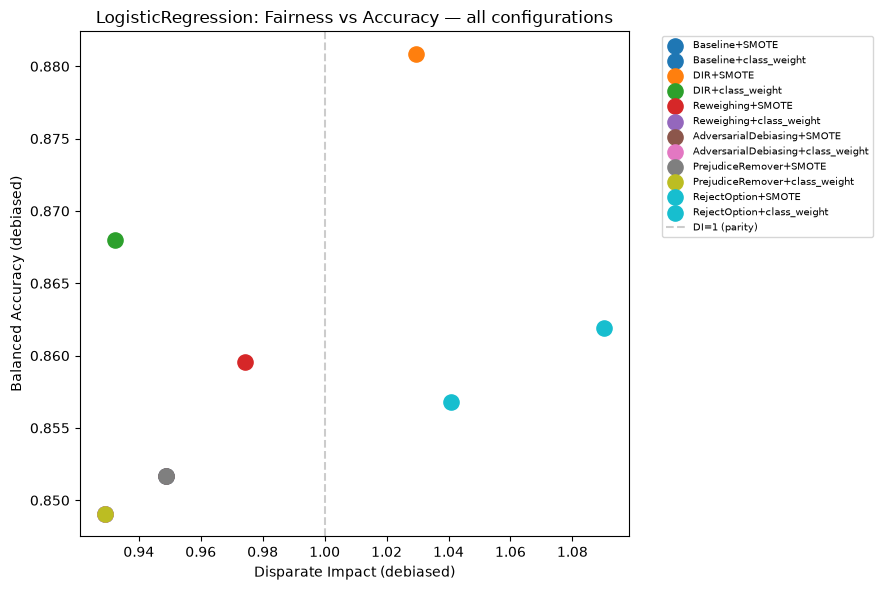

In [18]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(configs)))
for (d, i, _), c in zip(configs, colors):
    row = df_lr[(df_lr['Debiasing'] == d) & (df_lr['Imbalance'] == i)].iloc[0]
    ax.scatter(row['DI (deb)'], row['BA (deb)'], s=120, c=[c], label=f'{d}+{i}')
ax.axvline(1.0, color='gray', ls='--', alpha=0.4, label='DI=1 (parity)')
ax.set_xlabel('Disparate Impact (debiased)')
ax.set_ylabel('Balanced Accuracy (debiased)')
ax.set_title('LogisticRegression: Fairness vs Accuracy — all configurations')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()